In [1]:
import os 
os.getcwd()

'/Users/mariojrzolv/Projects/ml-projects/mall-customer-segmentation/notebooks'

In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/Mall_Customers.csv") 
print("Firsts rows...", df.head()) 
print("========================") 
print("DataFrame Info", df.info())
df.describe().T

Firsts rows...    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
DataFrame Info None


,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


In [3]:
print(df.isnull().sum())
print("============================")
print(df.duplicated().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
0


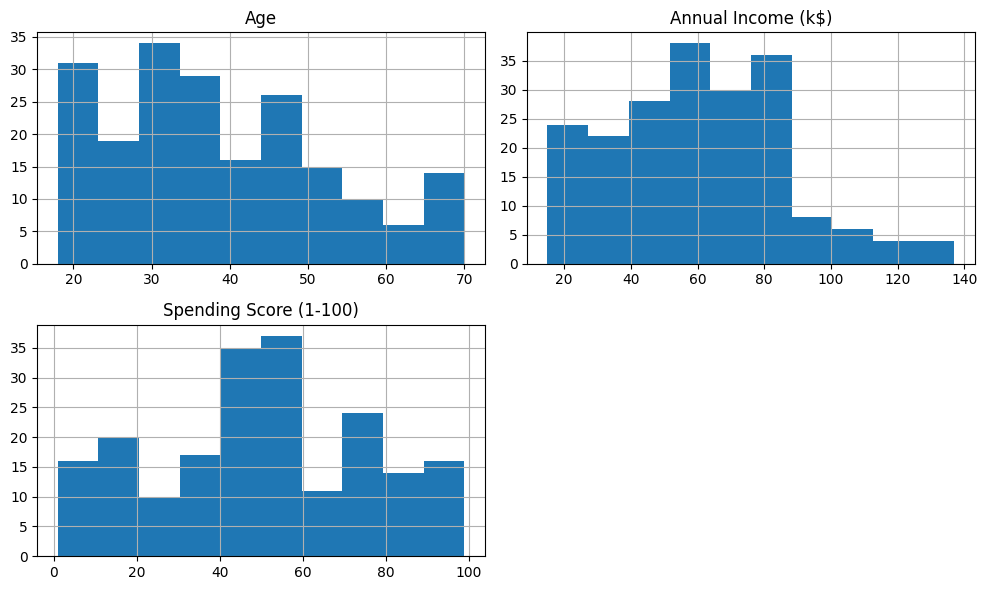

In [4]:
import matplotlib.pyplot as plt 

df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].hist(figsize = (10, 6))
plt.tight_layout()
plt.show()

In [5]:
corr = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].corr()
corr 

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


In [6]:
features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"] 
X = df[features].copy()

In [7]:
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X)

In [9]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA() 
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance) 

print(f"Explained Variance: {explained_variance}") 
print(f"Cumulative Variance: {cumulative_variance}")

Explained Variance: [0.44266167 0.33308378 0.22425454]
Cumulative Variance: [0.44266167 0.77574546 1.        ]


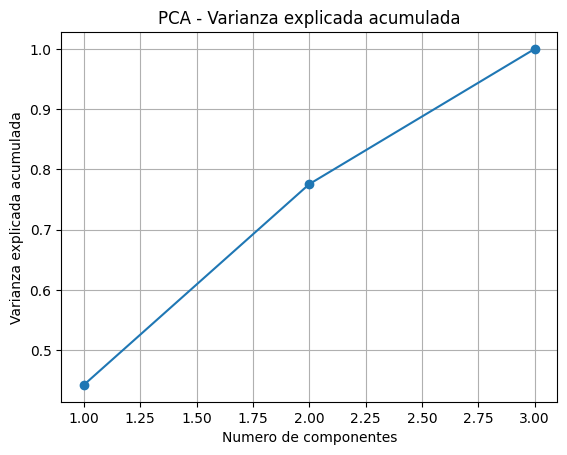

In [10]:
import matplotlib.pyplot as plt 

plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker = 'o')
plt.xlabel("Numero de componentes") 
plt.ylabel("Varianza explicada acumulada") 
plt.title("PCA - Varianza explicada acumulada") 
plt.grid(True) 
plt.show()


In [11]:
pca_2 = PCA(n_components = 2) 

X_pca_2 = pca_2.fit_transform(X_scaled) 

In [12]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 5, random_state = 42, n_init = 10) 
clusters = kmeans.fit_predict(X_scaled) 

df["clusters"] = clusters 

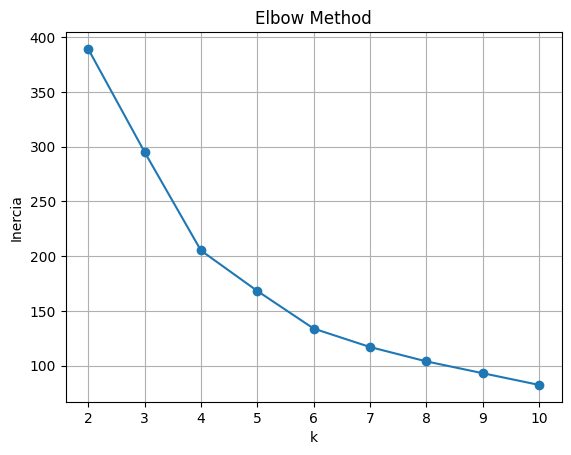

In [13]:
inertias = []
k_range = range(2, 11) 

for k in k_range: 
    model = KMeans(n_clusters = k, random_state = 42, n_init = 10)
    model.fit(X_scaled)
    inertias.append(model.inertia_) 

plt.plot(k_range, inertias, marker = 'o')
plt.xlabel("k")
plt.ylabel("Inercia")
plt.title("Elbow Method") 
plt.grid(True) 
plt.show()

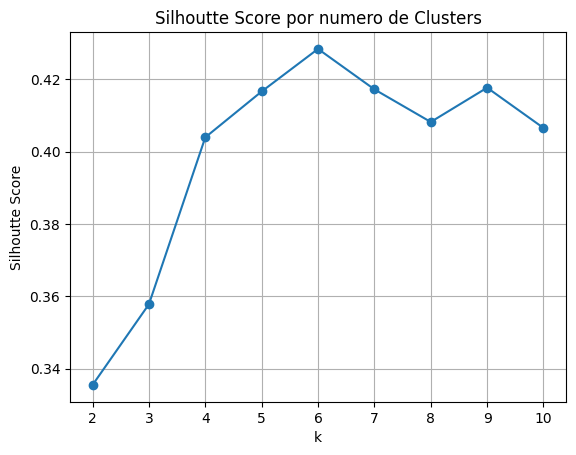

In [16]:
from sklearn.metrics import silhouette_score 

sil_scores = [] 

for k in k_range: 
    model = KMeans(n_clusters = k, random_state = 42, n_init = 10) 
    labels = model.fit_predict(X_scaled) 
    score = silhouette_score(X_scaled, labels) 
    sil_scores.append(score) 

plt.plot(k_range, sil_scores, marker = 'o') 
plt.xlabel("k") 
plt.ylabel("Silhoutte Score") 
plt.title("Silhoutte Score por numero de Clusters") 
plt.grid(True) 
plt.show() 


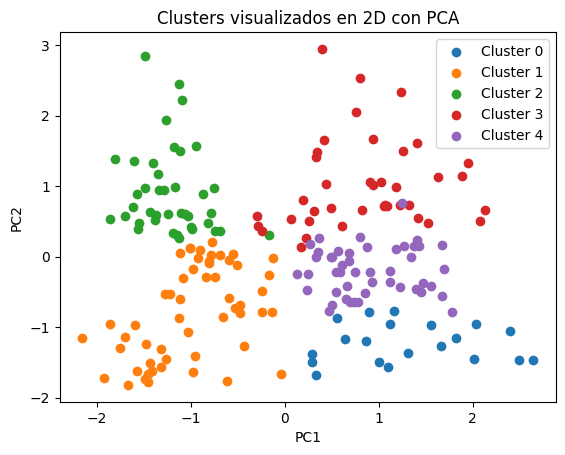

In [17]:
best_k = 5
kmeans = KMeans(n_clusters = best_k, random_state = 42, n_init = 10)
labels = kmeans.fit_predict(X_scaled)

df["cluster"] = labels 

pca_vis = PCA(n_components = 2) 
X_vis = pca_vis.fit_transform(X_scaled) 

plot_df = pd.DataFrame(X_vis, columns = ["PC1", "PC2"]) 
plot_df["cluster"] = labels 

for cluster_id in sorted(plot_df["cluster"].unique()):
    cluster_data = plot_df[plot_df["cluster"] == cluster_id] 
    plt.scatter(cluster_data["PC1"], cluster_data["PC2"], label = f"Cluster {cluster_id}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters visualizados en 2D con PCA") 
plt.legend()
plt.show()

In [18]:
cluster_profile = df.groupby("cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean()
cluster_profile 

,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064
